In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [3]:
df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Titanic dataset loaded successfully!
Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [5]:
# Select features and target

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features].copy()
y = df["survived"].copy()

# Handle missing values
X["age"] = X["age"].fillna(X["age"].median())
X["embarked"] = X["embarked"].fillna(X["embarked"].mode()[0])

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nRemaining missing values:")
print(X.isnull().sum())

Features shape: (891, 7)
Target shape: (891,)

Remaining missing values:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [6]:
# Convert categorical columns into numeric values

X = pd.get_dummies(
    X,
    columns=["sex", "embarked"],
    drop_first=True
)

print("Encoded Features:")
print(X.head())

print("\nEncoded Shape:", X.shape)

Encoded Features:
   pclass   age  sibsp  parch     fare  sex_male  embarked_Q  embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True

Encoded Shape: (891, 8)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Logistic Regression model
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully!")
print("Predictions generated successfully!")

Logistic Regression model trained successfully!
Predictions generated successfully!


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

# ROC-AUC using probabilities
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Evaluation")
print("--------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Evaluation
--------------------------------
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1 Score : 0.7244
ROC-AUC  : 0.8433

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



### Logistic Regression - Interpretation

The Logistic Regression model achieved an accuracy of approximately 80.45%.
The precision is 79.31%, while the recall is 66.67%.
The F1 score is 72.44%, and the ROC-AUC score is 84.33%.
The results indicate that the model provides a reasonable baseline for predicting passenger survival.

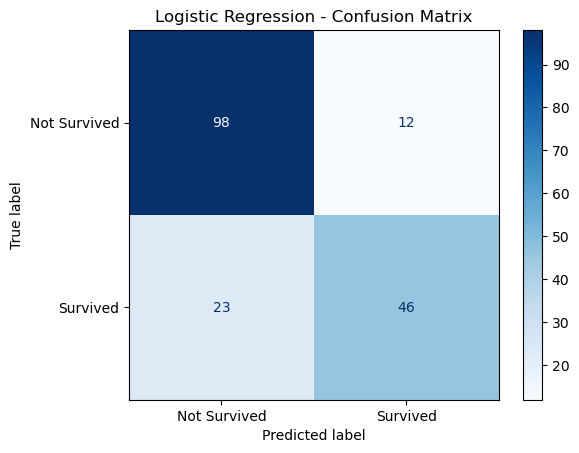

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["Not Survived", "Survived"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Logistic Regression - Confusion Matrix Interpretation

The confusion matrix shows 98 true negatives and 46 true positives.
There are 12 false positives and 23 false negatives.
The model correctly identifies many passengers in both classes, but some survived passengers are predicted as not survived.

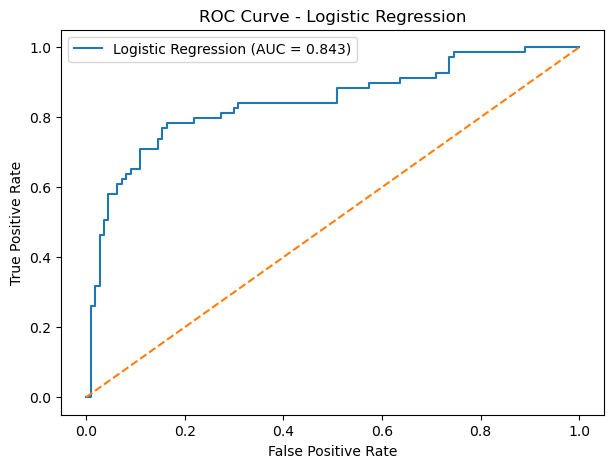

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)
roc_auc = roc_auc_score(y_test, y_prob_logistic)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

### ROC Curve - Interpretation

The ROC curve shows the performance of the Logistic Regression model across different classification thresholds.
The ROC-AUC score is 0.843, indicating that the model has good ability to distinguish between the two survival classes.

In [14]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Predictions
y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree model trained successfully!")
print("Predictions generated successfully!")

Decision Tree model trained successfully!
Predictions generated successfully!


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Evaluation")
print("------------------------")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1 Score :", round(f1_tree, 4))
print("ROC-AUC  :", round(roc_auc_tree, 4))

Decision Tree Evaluation
------------------------
Accuracy : 0.7654
Precision: 0.7547
Recall   : 0.5797
F1 Score : 0.6557
ROC-AUC  : 0.7971


### Decision Tree - Interpretation

The Decision Tree model achieved an accuracy of 76.54%.
The precision is 75.47%, recall is 57.97%, and F1 score is 65.57%.
The ROC-AUC score is 79.71%.
The model provides a useful non-linear baseline for comparison with Logistic Regression.

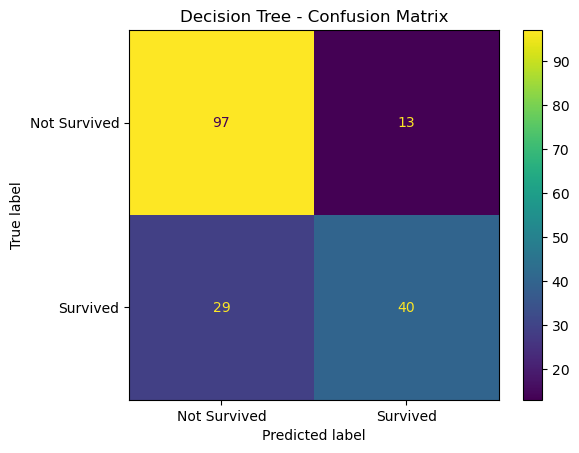

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    display_labels=["Not Survived", "Survived"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Predictions
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully!")
print("Predictions generated successfully!")

Random Forest model trained successfully!
Predictions generated successfully!


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Evaluation")
print("------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest Evaluation
------------------------
Accuracy : 0.8156
Precision: 0.7812
Recall   : 0.7246
F1 Score : 0.7519
ROC-AUC  : 0.8344


In [19]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_tree,
        recall_rf
    ],
    "F1 Score": [
        f1,
        f1_tree,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_tree,
        roc_auc_rf
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8433
1,Decision Tree,0.7654,0.7547,0.5797,0.6557,0.7971
2,Random Forest,0.8156,0.7812,0.7246,0.7519,0.8344


### Model Comparison - Interpretation

Three classification models were evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Logistic Regression provides a strong baseline with an ROC-AUC of 0.8433.
Decision Tree achieved an ROC-AUC of 0.7971.
Random Forest achieved an accuracy of 0.8156 and an ROC-AUC of 0.8344.

The results will be used as the baseline before addressing class imbalance with SMOTE and performing hyperparameter tuning.

In [20]:
# Check target class distribution

print("Class Distribution:")
print(y.value_counts())

print("\nClass Distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Class Distribution:
survived
0    549
1    342
Name: count, dtype: int64

Class Distribution (%):
survived
0    61.62
1    38.38
Name: proportion, dtype: float64


### Class Imbalance - Interpretation

The target variable contains 549 passengers who did not survive (61.62%) and 342 passengers who survived (38.38%).

The two classes are not evenly distributed. Therefore, class imbalance should be considered before further model improvement.

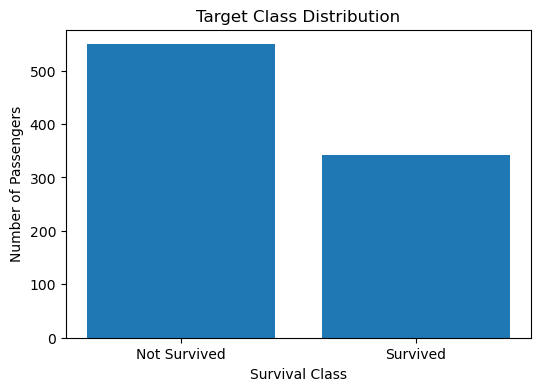

In [21]:
import matplotlib.pyplot as plt

class_counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not Survived", "Survived"], class_counts.values)
plt.xlabel("Survival Class")
plt.ylabel("Number of Passengers")
plt.title("Target Class Distribution")
plt.show()

In [23]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nBefore SMOTE shape:", X_train.shape)
print("After SMOTE shape:", X_train_smote.shape)

Before SMOTE:
survived
0    439
1    273
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

Before SMOTE shape: (712, 8)
After SMOTE shape: (878, 8)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Logistic Regression model for SMOTE data
logistic_model_smote = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

# Train the model
logistic_model_smote.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_logistic_smote = logistic_model_smote.predict(X_test)

print("Logistic Regression with SMOTE trained successfully!")
print("Predictions generated successfully!")

Logistic Regression with SMOTE trained successfully!
Predictions generated successfully!


In [26]:
y_pred_logistic_smote

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0])

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy_smote = accuracy_score(y_test, y_pred_logistic_smote)
precision_smote = precision_score(y_test, y_pred_logistic_smote)
recall_smote = recall_score(y_test, y_pred_logistic_smote)
f1_smote = f1_score(y_test, y_pred_logistic_smote)

print("SMOTE Logistic Regression Evaluation")
print("------------------------------------")
print("Accuracy :", round(accuracy_smote, 4))
print("Precision:", round(precision_smote, 4))
print("Recall   :", round(recall_smote, 4))
print("F1 Score :", round(f1_smote, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic_smote))

SMOTE Logistic Regression Evaluation
------------------------------------
Accuracy : 0.7821
Precision: 0.7027
Recall   : 0.7536
F1 Score : 0.7273

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       110
           1       0.70      0.75      0.73        69

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.79      0.78      0.78       179



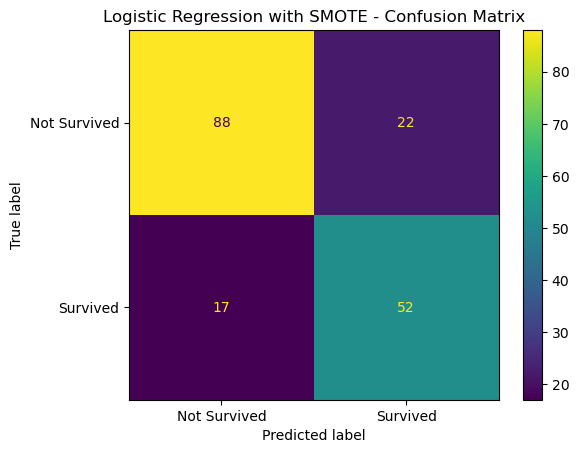

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_smote = confusion_matrix(y_test, y_pred_logistic_smote)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=["Not Survived", "Survived"]
)

disp.plot()
plt.title("Logistic Regression with SMOTE - Confusion Matrix")
plt.show()

### Interpretation – Logistic Regression with SMOTE Confusion Matrix

The confusion matrix shows that the Logistic Regression model with SMOTE correctly predicted 88 passengers who did not survive and 52 passengers who survived. It incorrectly predicted 22 non-survivors as survivors and 17 survivors as non-survivors. The model therefore performs reasonably well for both classes, while some misclassifications remain.

In [29]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train the model on SMOTE data
decision_tree.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_dt = decision_tree.predict(X_test)

print("Decision Tree trained successfully!")
print("Predictions generated successfully!")

Decision Tree trained successfully!
Predictions generated successfully!


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Separate numerical and categorical features
numeric_features = ['pclass', 'age', 'fare']
categorical_features = ['sex', 'embarked']

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Logistic Regression pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [14]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully.
First 10 predictions: [0 0 0 0 1 0 1 0 0 0]


In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.770949720670391

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       110
           1       0.72      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179


Confusion Matrix:
[[92 18]
 [23 46]]


### Model Evaluation Interpretation

The model achieved an accuracy of approximately 77.09% on the test dataset.

The classification report shows balanced performance across both classes, with an F1-score of 0.82 for Class 0 and 0.69 for Class 1.

The confusion matrix shows that the model correctly classified 92 samples from Class 0 and 46 samples from Class 1, while 18 and 23 samples were misclassified respectively.

Overall, the model provides a reasonable baseline performance for the classification task.

In [15]:
# Make predictions using the trained model
predictions = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:", predictions[:10])

Predictions generated successfully!
First 10 predictions: [0 0 0 0 1 0 1 0 0 0]


## Prediction

### Prediction Interpretation

The trained Logistic Regression model successfully generated predictions for the test dataset.

The first 10 predictions show the predicted class labels for the test samples.

These predictions can be compared with the actual target values to evaluate the model's predictive performance.

# Module 2 Summary

In this module, exploratory data analysis and machine learning modeling were performed on the dataset.

The data was prepared by handling missing values and separating numerical and categorical features. A preprocessing pipeline was created using imputation, scaling, and one-hot encoding.

A Logistic Regression model was trained using the training dataset and evaluated on the test dataset. The model achieved an accuracy of approximately 77.09%.

The classification report and confusion matrix were used to evaluate the model performance. Predictions were also generated for the test dataset.

Overall, the modeling workflow demonstrates the complete process from data preprocessing to model training, evaluation, and prediction.

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Grid Search with 3-fold Cross Validation
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy'
)

# Train
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation Accuracy: 0.8357


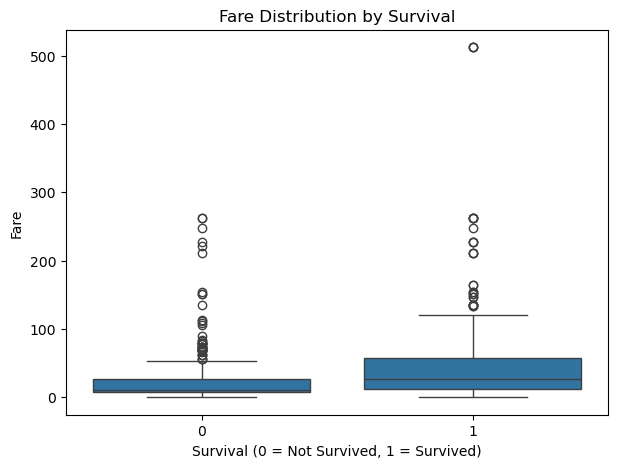

survived
0    22.117887
1    48.395408
Name: fare, dtype: float64


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="survived", y="fare")

plt.title("Fare Distribution by Survival")
plt.xlabel("Survival (0 = Not Survived, 1 = Survived)")
plt.ylabel("Fare")
plt.show()

print(df.groupby("survived")["fare"].mean())

Feature Importance:
sex_male      0.334397
fare          0.212239
age           0.190968
pclass        0.124553
sibsp         0.054767
parch         0.043976
embarked_S    0.029199
embarked_Q    0.009902
dtype: float64


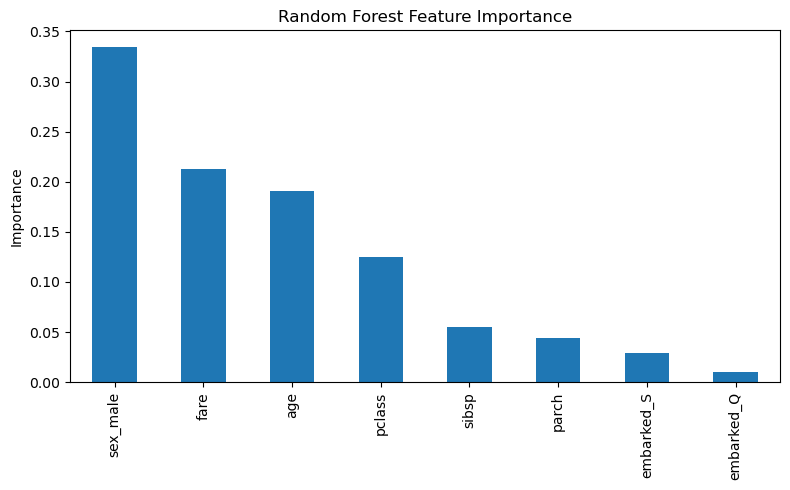

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Get best Random Forest model from GridSearchCV
best_rf = grid_search.best_estimator_

# Feature importance
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(importance)

# Plot
importance.plot(kind="bar", figsize=(8, 5))
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [33]:
import joblib

best_model = grid_search.best_estimator_

joblib.dump(best_model, "titanic_random_forest_model.joblib")

print("Model saved successfully!")

Model saved successfully!


In [34]:
import joblib

loaded_model = joblib.load("titanic_random_forest_model.joblib")

test_predictions = loaded_model.predict(X_test)

print("Saved model loaded successfully!")
print("First 10 predictions:", test_predictions[:10])

Saved model loaded successfully!
First 10 predictions: [0 0 0 0 1 0 1 1 1 0]
